In [64]:
#importing required libraries
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

## Defining the function

In [65]:
#function for plotting the initial and final snapshot of the given dataset
def plot_particle_positions(base_path, positions, N, dataset_name):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    plt.suptitle(f'Particle Positions for {dataset_name}')
    titles = [f'initial snapshot', f'final snapshot']

    for ax, title, i in zip(axes, titles, positions):
        file_path = f"{base_path}{i}"

        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        data = np.fromfile(file_path, dtype=np.float64)
        reshaped_data = data.reshape(N, 2)

        x = reshaped_data[:, 0]
        y = reshaped_data[:, 1]

        ax.scatter(x, y, s=4, alpha=0.5)
        ax.set_title(title)
        ax.set_xlabel('X Position')
        ax.set_ylabel('Y Position')
        ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

#mean square displacment for the given dataset
def mean_square_displacement(base_path, positions, N, dataset_name):
    dt = 0.001 #seconds
    msd_values = []
    time_diff = []
    start, end = positions

    #initial positions
    file_path = f"{base_path}{start}"
    initial_data = np.fromfile(file_path, dtype=np.float64)
    reshaped_data = initial_data.reshape(N, 2)
    xi = reshaped_data[:, 0]
    yi = reshaped_data[:, 1]

    for i in range(start+10, end+1, 10):
        file_path = f"{base_path}{i}"

        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        data = np.fromfile(file_path, dtype=np.float64)
        reshaped_data = data.reshape(N, 2)
        xf = reshaped_data[:, 0]
        yf = reshaped_data[:, 1]

        msd = np.mean((xf - xi)**2 + (yf -  yi)**2)
        delta_t = dt * i

        msd_values.append(msd)
        time_diff.append(delta_t)


    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    plt.suptitle(f'MSD vs Time ({dataset_name})')

    ax[0].plot(time_diff, msd_values)
    ax[0].set_title('MSD vs Time')
    ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('MSD')
    ax[0].grid(True)

    ax[1].loglog(time_diff, msd_values)
    ax[1].set_title('MSD vs Time (Log-Log Scale)')
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('MSD')
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()
    return msd_values, time_diff

## Base path for the given datasets

In [73]:
#dataset 1
base_path_1 = rf'/home/Interstellar/Desktop/Computational Methods/Assignment-10(Brownian Motion)/Active_BrownianParticle_DataSet/Finalized_data/DataSet1/part/POSITION'

#dataset 2
base_path_2 = rf'/home/Interstellar/Desktop/Computational Methods/Assignment-10(Brownian Motion)/Active_BrownianParticle_DataSet/Finalized_data/DataSet2/part/NOISE_tra'

#dataset 3
base_path_3 = rf'/home/Interstellar/Desktop/Computational Methods/Assignment-10(Brownian Motion)/Active_BrownianParticle_DataSet/Finalized_data/DataSet3/part/POSITION'

#dataset 4
base_path_4 = rf"/home/Interstellar/Desktop/Computational Methods/Assignment-10(Brownian Motion)/Active_BrownianParticle_DataSet/Finalized_data/DataSet4/part/POSITION"

## Datasets information

In [72]:
#total number of the given particals
N1, N2, N3, N4 = 3517, 3517, 3517, 3000

#final snapshots
fs1, fs2, fs3, fs4 =  10000, 10000, 200000, 1000000

# 1) Ininial and final snapshot for the given datasets

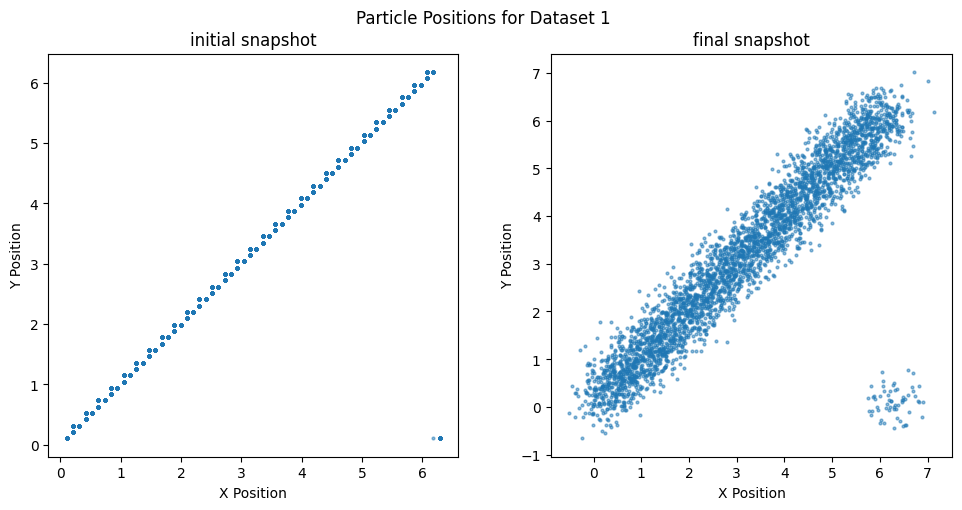

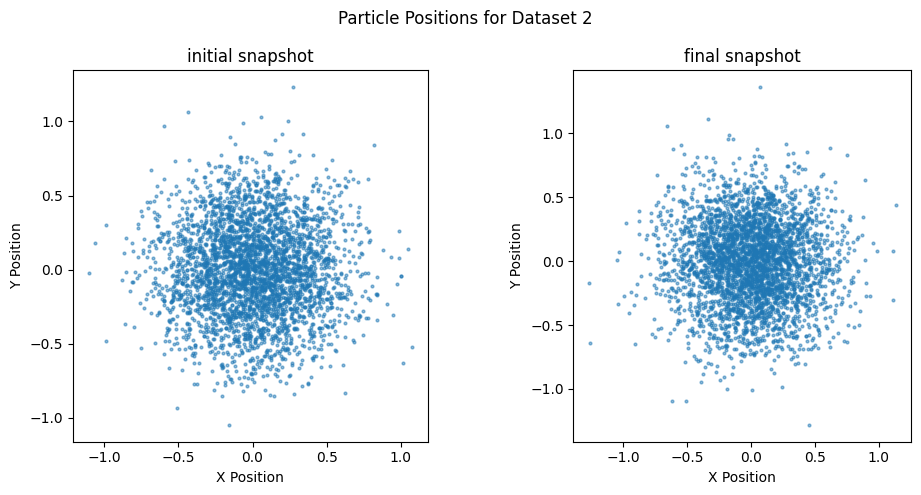

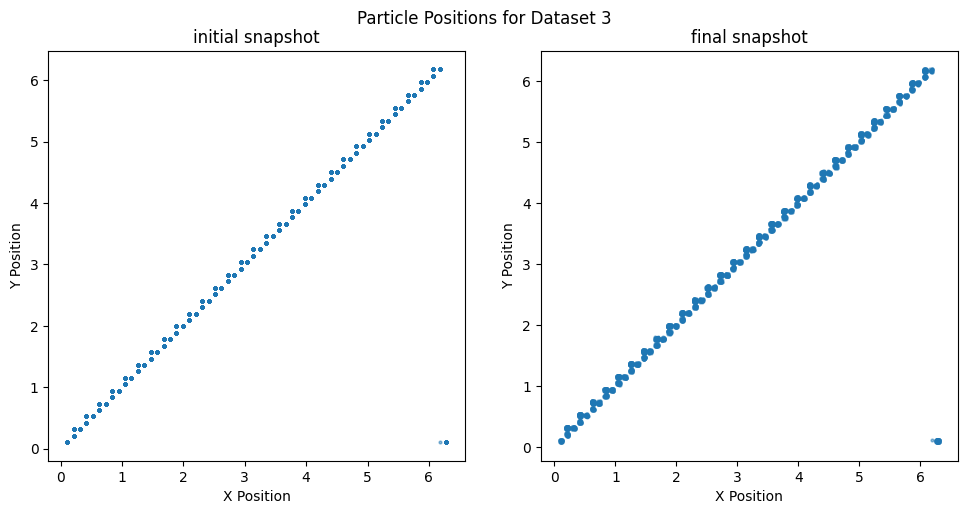

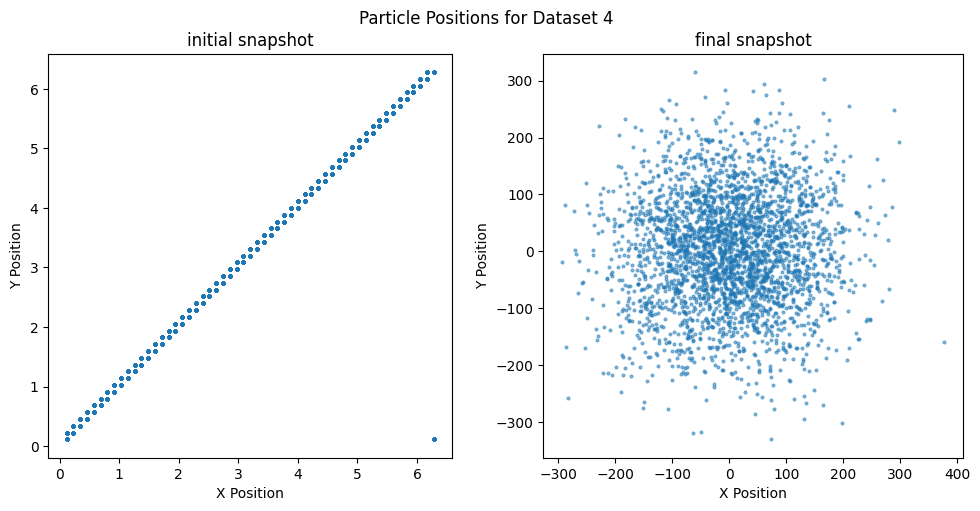

In [68]:
plot_particle_positions(base_path_1, [0, fs1], N1, "Dataset 1")
plot_particle_positions(base_path_2, [0, fs2], N2, "Dataset 2")
plot_particle_positions(base_path_3, [0, fs3], N3, 'Dataset 3')
plot_particle_positions(base_path_4, [0, fs4], N4, "Dataset 4")

# 2) Mean square displacement

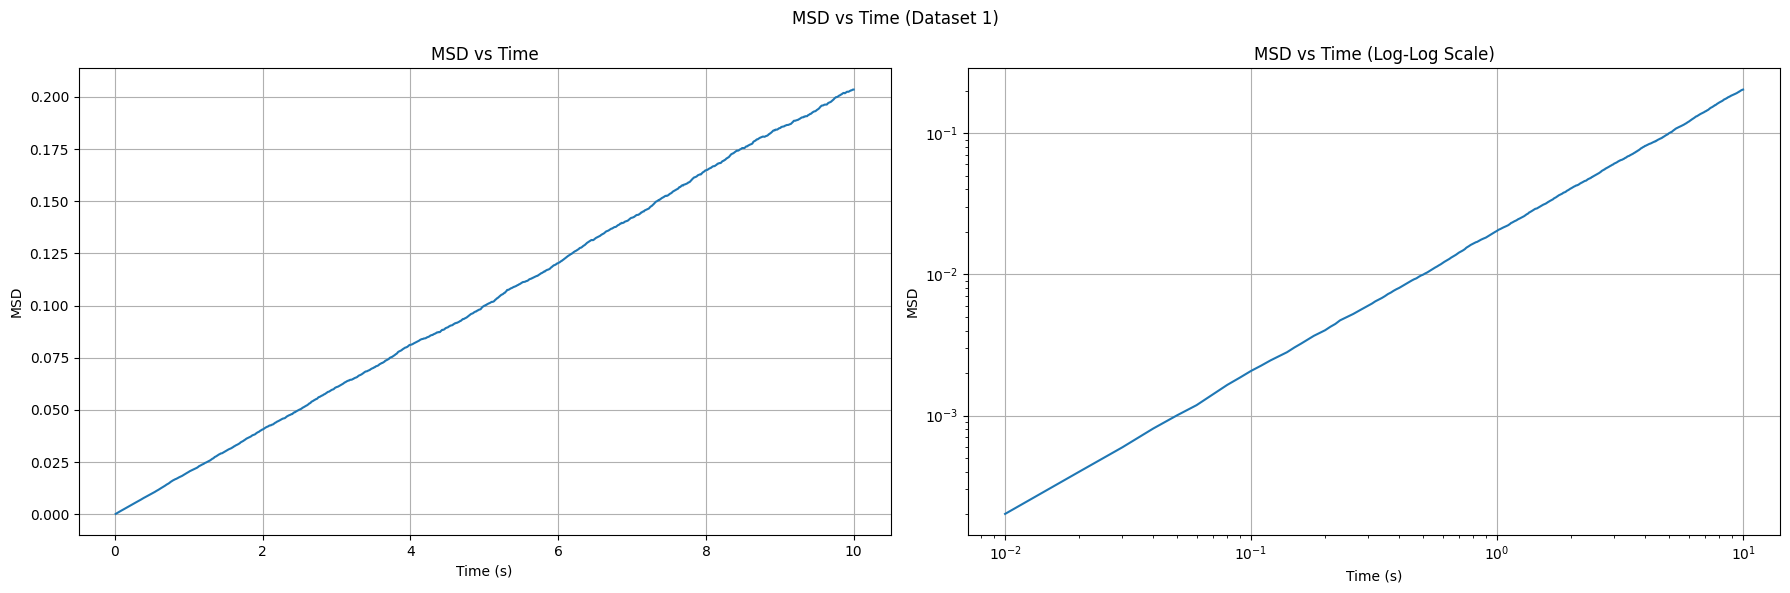

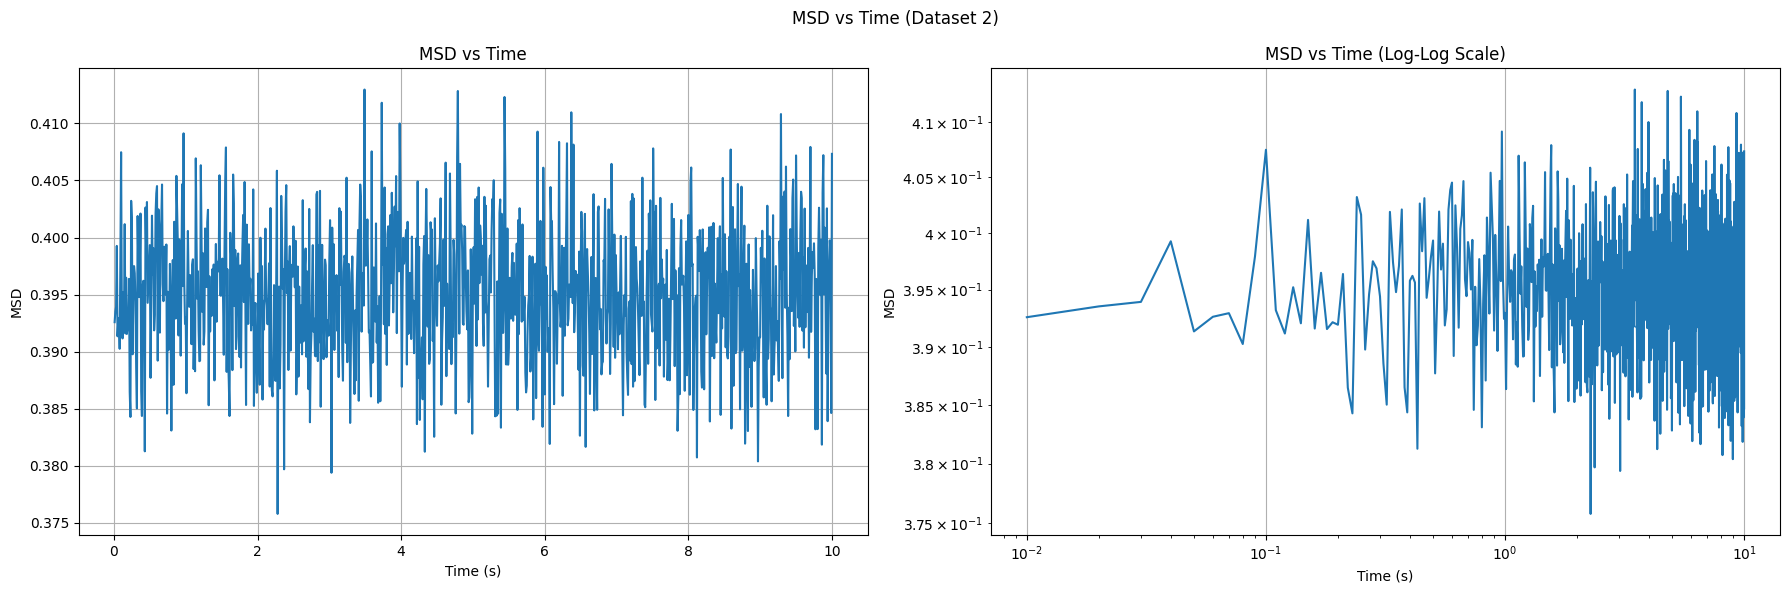

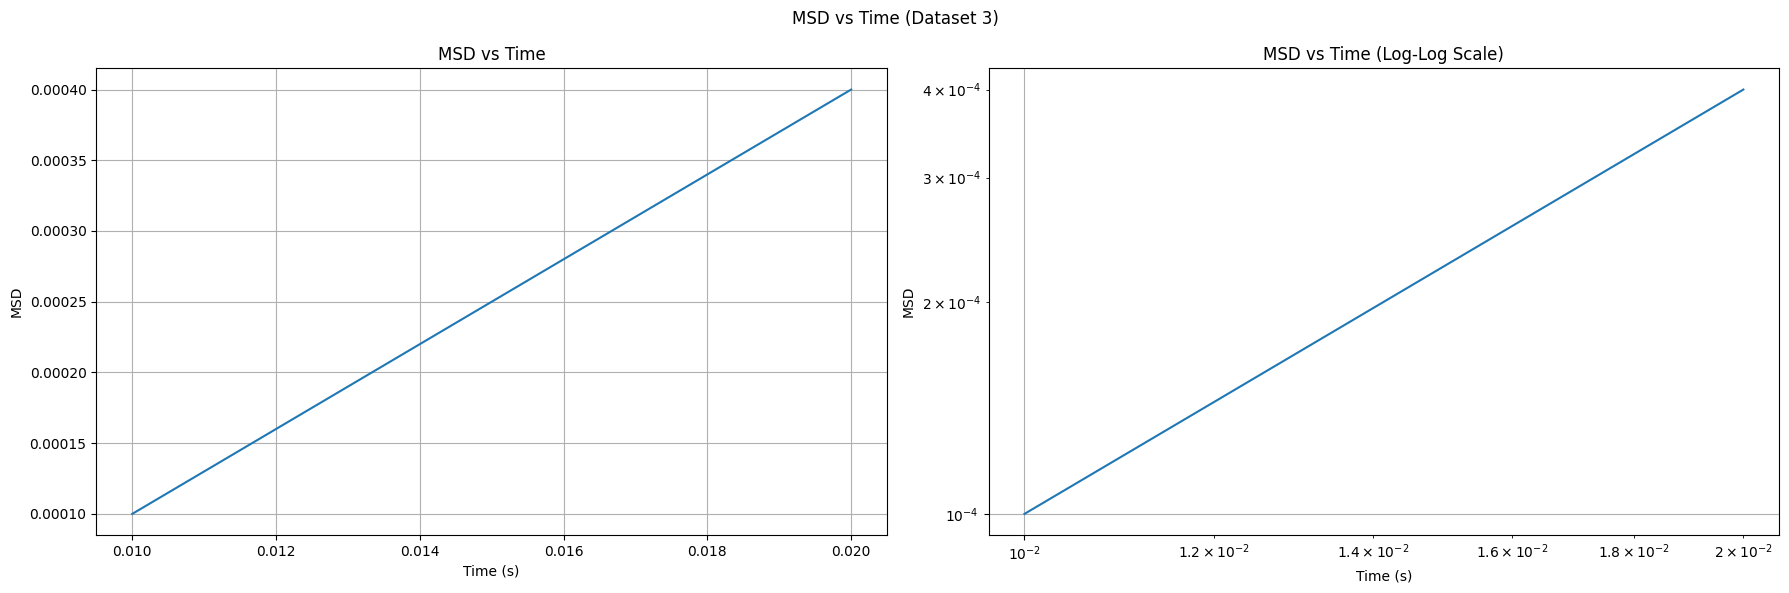

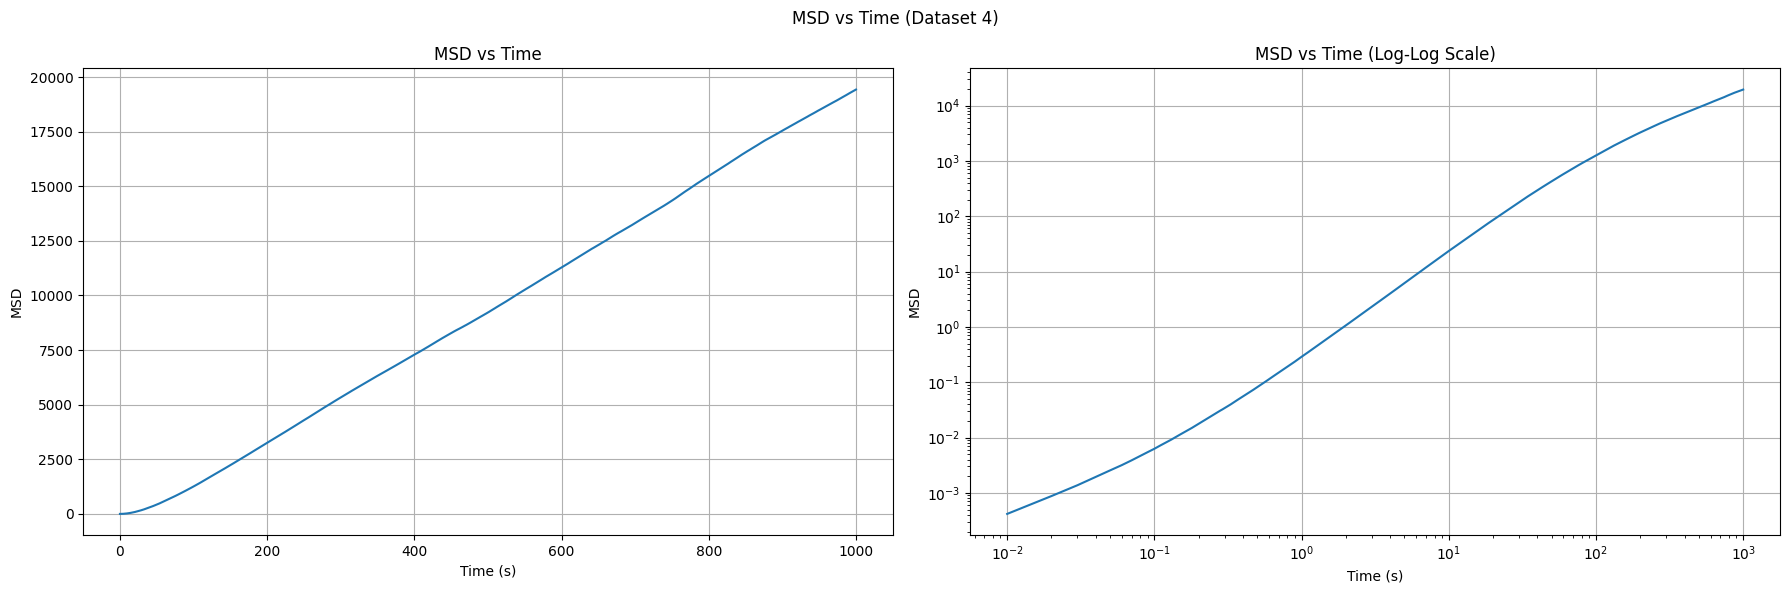

In [69]:
msd_values1, time_diff1 = mean_square_displacement(base_path_1, [0, fs1], N1, "Dataset 1")
msd_values2, time_diff2 = mean_square_displacement(base_path_2, [0, fs2], N2, "Dataset 2")
msd_values3, time_diff3 = mean_square_displacement(base_path_3, [0, fs3], N3, "Dataset 3")
msd_values4, time_diff4 = mean_square_displacement(base_path_4, [0, fs4], N4, "Dataset 4")

# 4) Calculate $\alpha$ and c

In [78]:
def linear_fit(t, m, c):
    return m*t + c

#linear curve fit using scipy​
popt1, _ = curve_fit(linear_fit, np.log(time_diff1), np.log(msd_values1))
popt2, _ = curve_fit(linear_fit, np.log(time_diff2), np.log(msd_values2))
popt3, _ = curve_fit(linear_fit, np.log(time_diff3), np.log(msd_values3))
popt4, _ = curve_fit(linear_fit, np.log(time_diff4), np.log(msd_values4))

#extract parameters
params = [popt1, popt2, popt3, popt4]

for i, (m, c) in enumerate(params, start=1):
    alpha = m
    C = np.exp(c)

    print(f"Dataset {i}:")
    print(f"\u03B1 = {alpha:.4f}")
    print(f"C = {C:.4f}")
    print()

Dataset 1:
α = 1.0031
C = 0.0202

Dataset 2:
α = -0.0003
C = 0.3951

Dataset 3:
α = 2.0000
C = 0.9999

Dataset 4:
α = 1.3609
C = 1.9393



/tmp/ipykernel_51433/3108333402.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  popt3, _ = curve_fit(linear_fit, np.log(time_diff3), np.log(msd_values3))


# 5) 

D_r = 0.0986


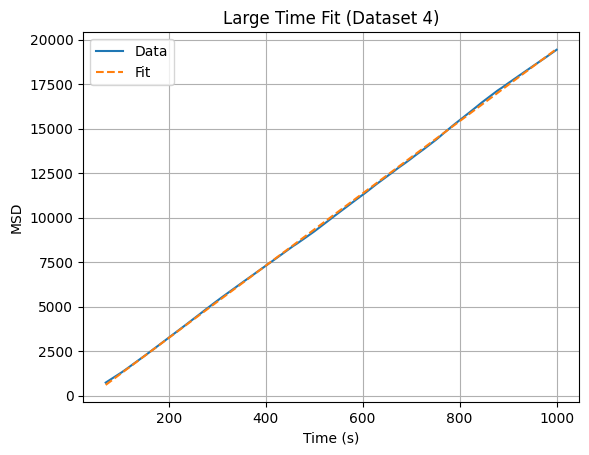

In [ ]:
#Dataset 1: Brownian Motion
D_t = np.exp(popt1[1])/4

#Dataset 2: 

#Dataset 3: Ballistic Motion
v = np.sqrt(np.exp(popt3[1]))

#Dataset 4: Active Brownian Motion
t_large = np.array(time_diff4[7000:])
msd_large = np.array(msd_values4[7000:])

popt_large, _ = curve_fit(linear_fit, t_large, msd_large)
slope_large = popt_large[0]

Dr = (2 * v**2) / slope_large

print(f"D_r = {Dr:.4f}")

plt.plot(t_large, msd_large, label='Data')
plt.plot(t_large, linear_fit(t_large, *popt_large), '--', label='Fit')
plt.xlabel('Time (s)')
plt.ylabel('MSD')
plt.title('Large Time Fit (Dataset 4)')
plt.legend()
plt.grid()
plt.show()
